# 💼 Salary Prediction — Machine Learning Project

**Objective:** Build a machine learning model to predict employee salaries based on features like experience, education, job role, and more.

---

### 📌 Project Workflow
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Model Training (Random Forest & Linear Regression)
7. Model Evaluation & Comparison
8. Save the Best Model

## 📦 1. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 📂 2. Load Dataset

> We generate a realistic synthetic salary dataset. Replace `df` with `pd.read_csv('your_file.csv')` to use your own data.

In [26]:
# ── Generate Synthetic Salary Dataset ──────────────────────────────────────
np.random.seed(42)
n = 10000

education_levels = ['High School', "Bachelor's", "Master's", 'PhD']
job_roles        = ['Analyst', 'Engineer', 'Manager', 'Director', 'Intern']
departments      = ['IT', 'Finance', 'HR', 'Marketing', 'Operations']
genders          = ['Male', 'Female']

education  = np.random.choice(education_levels, n, p=[0.15, 0.45, 0.30, 0.10])
job_role   = np.random.choice(job_roles,        n, p=[0.25, 0.30, 0.20, 0.10, 0.15])
department = np.random.choice(departments,      n)
gender     = np.random.choice(genders,          n)
experience = np.random.randint(0, 30, n)
age        = 22 + experience + np.random.randint(0, 5, n)

edu_map  = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
role_map = {'Intern': 0, 'Analyst': 1, 'Engineer': 2, 'Manager': 3, 'Director': 4}

base_salary = (
    30000
    + np.array([edu_map[e]  for e in education])  * 8000
    + np.array([role_map[r] for r in job_role])   * 12000
    + experience * 1500
    + np.random.normal(0, 5000, n)
)
salary = np.clip(base_salary, 20000, 200000).astype(int)

df = pd.DataFrame({
    'Age':        age,
    'Gender':     gender,
    'Education':  education,
    'Job_Role':   job_role,
    'Department': department,
    'Experience': experience,
    'Salary':     salary
})

# Inject ~5 % missing values for realism
for col in ['Age', 'Experience']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

print("Dataset created successfully!")
print(f"Shape: {df.shape}")

Dataset created successfully!
Shape: (10000, 7)


In [27]:
df.head(10)

,Age,Gender,Education,Job_Role,Department,Experience,Salary
0,33.0,Male,Bachelor's,Engineer,Finance,9.0,73096
1,53.0,Male,PhD,Engineer,Marketing,27.0,119506
2,38.0,Female,Master's,Analyst,Operations,12.0,83769
3,49.0,Female,Bachelor's,Manager,Operations,26.0,112954
4,31.0,Male,Bachelor's,Engineer,HR,NaN,70749
5,53.0,Male,Bachelor's,Intern,IT,27.0,72682
6,36.0,Male,High School,Analyst,HR,12.0,53341
7,42.0,Female,Master's,Manager,IT,NaN,104459
8,23.0,Male,Master's,Director,HR,1.0,95317
9,55.0,Female,Master's,Director,HR,29.0,148451


In [28]:
df.shape

(10000, 7)

In [29]:
df.columns.tolist()

['Age',
 'Gender',
 'Education',
 'Job_Role',
 'Department',
 'Experience',
 'Salary']

In [30]:
df.dtypes

Age           float64
Gender            str
Education         str
Job_Role          str
Department        str
Experience    float64
Salary          int64
dtype: object

In [31]:
df.describe()

,Age,Experience,Salary
count,9500.000000,9500.000000,10000.000000
mean,38.473474,14.477895,84504.222600
std,8.802666,8.643787,21323.362947
min,22.000000,0.000000,20501.000000
25%,31.000000,7.000000,69265.750000
50%,38.000000,15.000000,84274.500000
75%,46.000000,22.000000,99502.000000
max,55.000000,29.000000,157188.000000


## 🔍 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

In [32]:
df.isnull().sum()

Age           500
Gender          0
Education       0
Job_Role        0
Department      0
Experience    500
Salary          0
dtype: int64

In [33]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 3.2 Target Variable — Salary Distribution

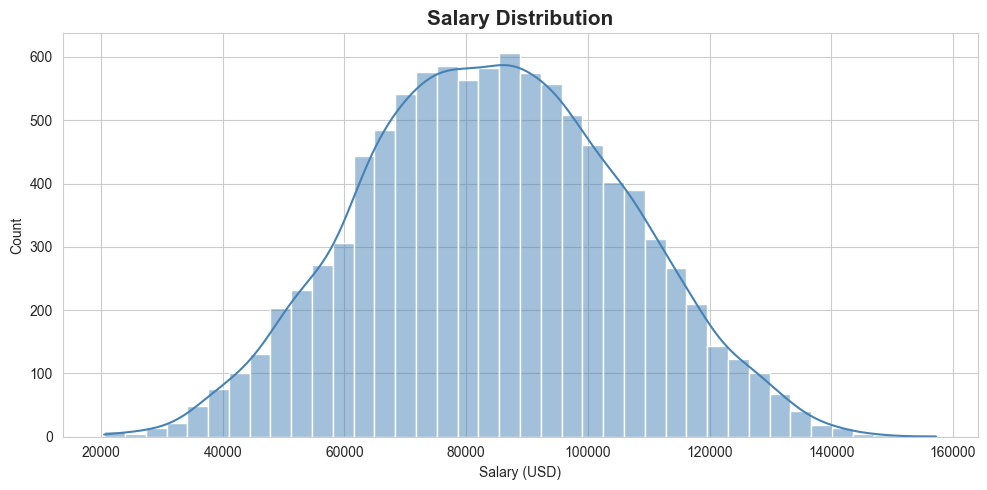

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Salary'], bins=40, kde=True, color='steelblue')
plt.title('Salary Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3.3 Salary by Categorical Features

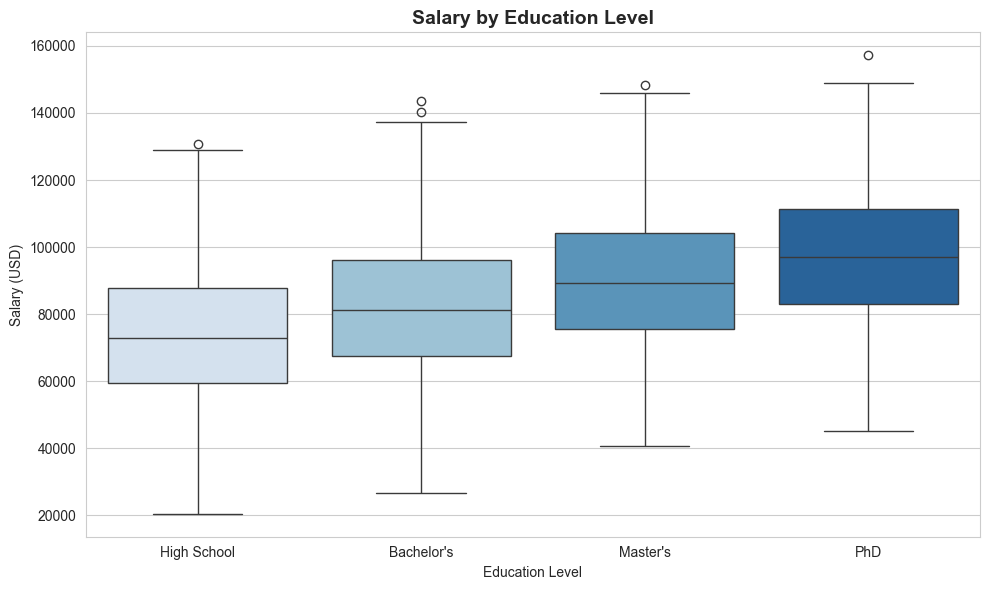

In [35]:
edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
sns.boxplot(data=df, x='Education', y='Salary', order=edu_order, palette='Blues')
plt.title('Salary by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

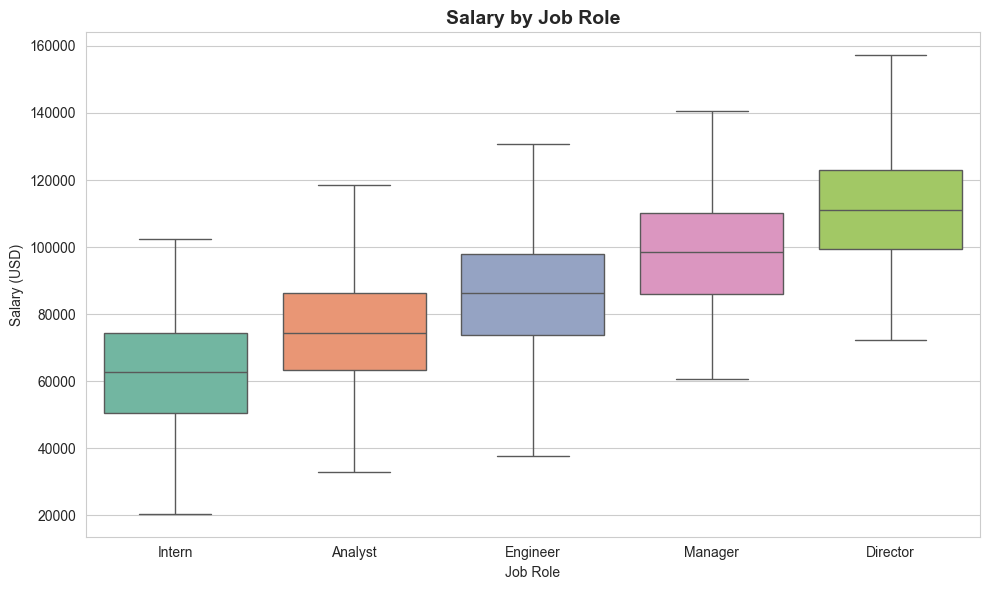

In [36]:
role_order = ['Intern', 'Analyst', 'Engineer', 'Manager', 'Director']
sns.boxplot(data=df, x='Job_Role', y='Salary', order=role_order, palette='Set2')
plt.title('Salary by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Job Role')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

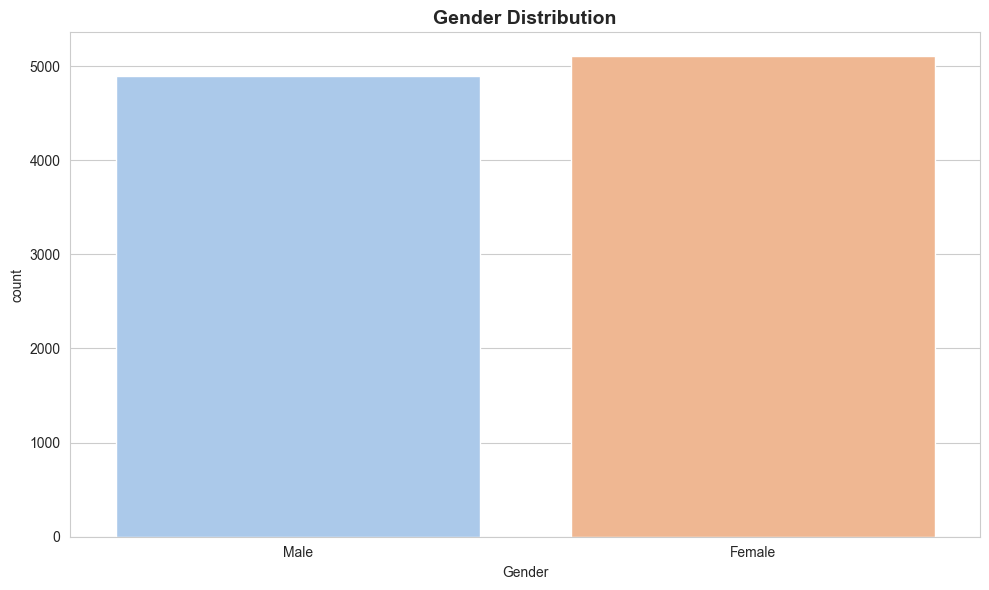

In [37]:
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

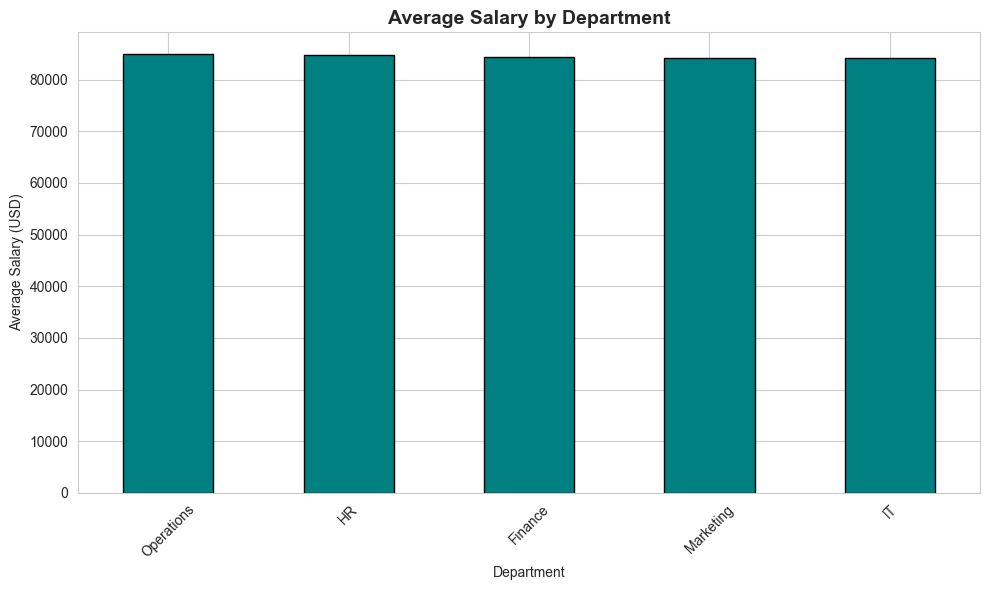

In [38]:
dept_avg = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)
dept_avg.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Salary by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Experience vs Salary (Scatter Plot)

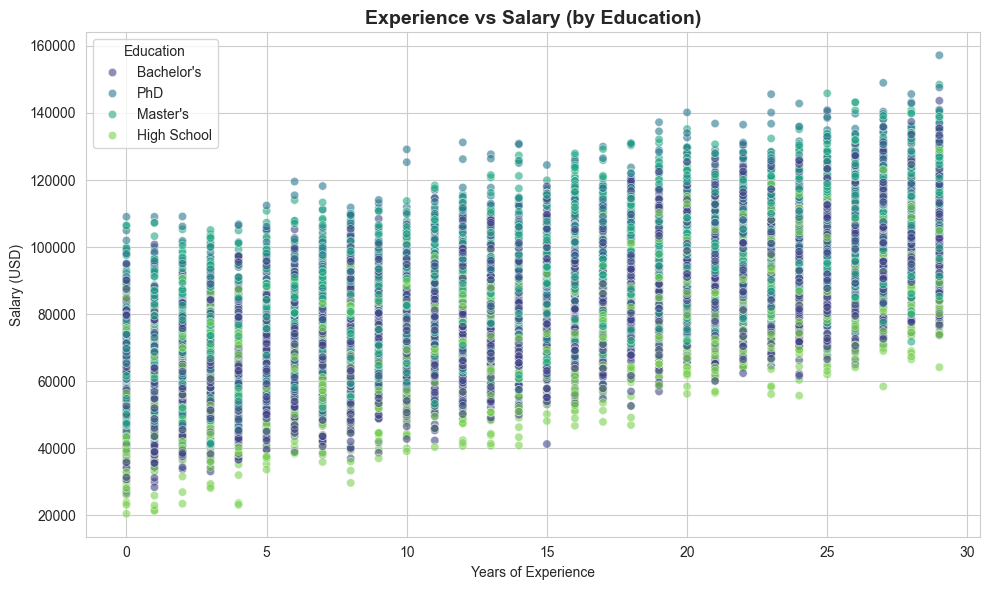

In [39]:
sns.scatterplot(data=df, x='Experience', y='Salary', hue='Education',
                palette='viridis', alpha=0.6)
plt.title('Experience vs Salary (by Education)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

## ⚙️ 4. Data Preprocessing

### 4.1 Handle Missing Values

In [40]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Experience'].fillna(df['Experience'].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Age           500
Gender          0
Education       0
Job_Role        0
Department      0
Experience    500
Salary          0
dtype: int64


### 4.2 Encode Categorical Variables

In [41]:
label_encoders = {}
categorical_cols = ['Gender', 'Education', 'Job_Role', 'Department']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Encoding complete. Unique values per column:")
df[categorical_cols].nunique()

Encoding complete. Unique values per column:


Gender        2
Education     4
Job_Role      5
Department    5
dtype: int64

## 📊 5. Feature Engineering & Correlation

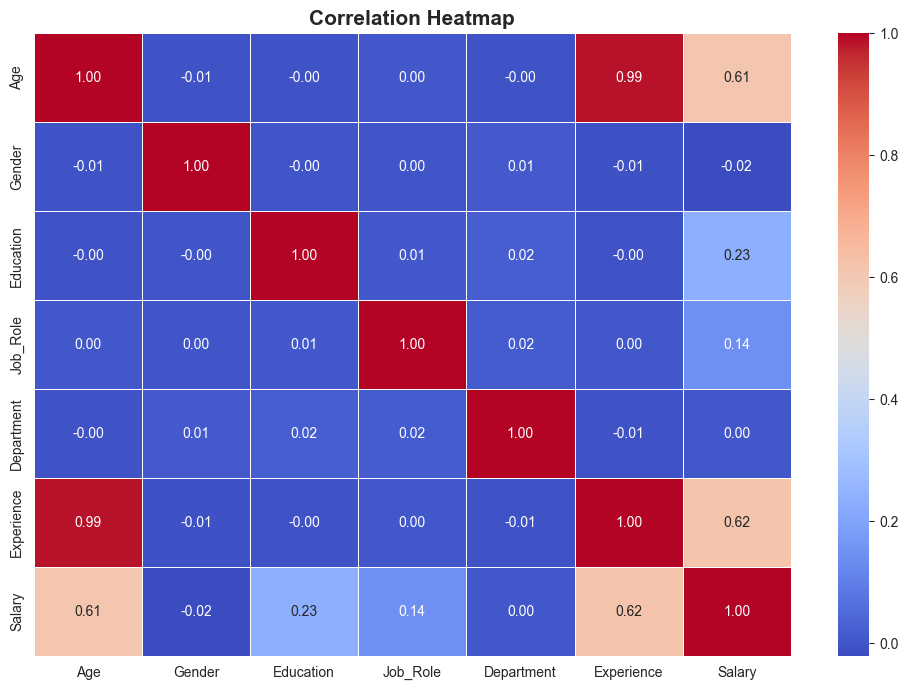

In [42]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Feature matrix shape:", X.shape)
print("Target vector shape: ", y.shape)

Feature matrix shape: (10000, 6)
Target vector shape:  (10000,)


In [44]:
X.head()

,Age,Gender,Education,Job_Role,Department,Experience
0,33.0,1,0,2,0,9.0
1,53.0,1,3,2,3,27.0
2,38.0,0,2,0,4,12.0
3,49.0,0,0,4,4,26.0
4,31.0,1,0,2,1,NaN


In [45]:
y.head()

0     73096
1    119506
2     83769
3    112954
4     70749
Name: Salary, dtype: int64

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (8000, 6)
Test set:     (2000, 6)


In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


## 🤖 6. Model Training

We train **three** regression models and compare them:
- Linear Regression (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor

### 6.1 Linear Regression

In [48]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print(f"Linear Regression  →  MAE: ${lr_mae:,.0f}  |  RMSE: ${lr_rmse:,.0f}  |  R²: {lr_r2:.4f}")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 6.2 Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print(f"Random Forest      →  MAE: ${rf_mae:,.0f}  |  RMSE: ${rf_rmse:,.0f}  |  R²: {rf_r2:.4f}")

### 6.3 Gradient Boosting Regressor

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2   = r2_score(y_test, gb_pred)

print(f"Gradient Boosting  →  MAE: ${gb_mae:,.0f}  |  RMSE: ${gb_rmse:,.0f}  |  R²: {gb_r2:.4f}")

## 📈 7. Model Evaluation & Comparison

In [ ]:
results_df = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE':    [f'${lr_mae:,.0f}', f'${rf_mae:,.0f}', f'${gb_mae:,.0f}'],
    'RMSE':   [f'${lr_rmse:,.0f}', f'${rf_rmse:,.0f}', f'${gb_rmse:,.0f}'],
    'R² Score': [f'{lr_r2:.4f}', f'{rf_r2:.4f}', f'{gb_r2:.4f}'],
    'Winner': [
        '✅' if lr_r2 == max(lr_r2, rf_r2, gb_r2) else '',
        '✅' if rf_r2 == max(lr_r2, rf_r2, gb_r2) else '',
        '✅' if gb_r2 == max(lr_r2, rf_r2, gb_r2) else ''
    ]
})
results_df

### 7.1 R² Score Comparison (Bar Chart)

In [ ]:
models  = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
r2_vals = [lr_r2, rf_r2, gb_r2]
colors  = ['#4C72B0', '#55A868', '#C44E52']

bars = plt.bar(models, r2_vals, color=colors, edgecolor='black', width=0.5)
plt.title('R² Score Comparison', fontsize=15, fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0, 1.05)
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Actual vs Predicted — Random Forest

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Salary (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Residual Plot — Random Forest

In [ ]:
residuals = y_test - rf_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=40, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Residual Distribution (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Residuals (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 7.4 Feature Importance — Random Forest

In [ ]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 💾 8. Save the Best Model

In [ ]:
best_model_name = models[np.argmax(r2_vals)]
best_model_obj  = [lr_model, rf_model, gb_model][np.argmax(r2_vals)]

joblib.dump(best_model_obj, 'salary_prediction_model.pkl')
joblib.dump(scaler,          'salary_scaler.pkl')
joblib.dump(label_encoders,  'salary_label_encoders.pkl')

print(f"✅ Best model  : {best_model_name}")
print(f"   R² Score   : {max(r2_vals):.4f}")
print("   Saved  → salary_prediction_model.pkl")

## 🔮 9. Predict on a New Employee

In [ ]:
# ── Encode a new sample the same way ──────────────────────────────────────
new_employee = {
    'Age':        30,
    'Gender':     'Female',
    'Education':  "Master's",
    'Job_Role':   'Engineer',
    'Department': 'IT',
    'Experience': 6
}

new_df = pd.DataFrame([new_employee])
for col in categorical_cols:
    new_df[col] = label_encoders[col].transform(new_df[col].astype(str))

predicted_salary = best_model_obj.predict(new_df)[0]
print(f"Predicted Salary for the new employee: ${predicted_salary:,.0f}")

---

## ✅ Conclusion

| Step | Summary |
|------|---------|
| **Dataset** | 10,000 employee records with 6 features |
| **EDA** | Visualised salary distributions, department averages, and correlations |
| **Preprocessing** | Imputed missing values, label-encoded categoricals, standardised numerics |
| **Models** | Linear Regression, Random Forest, Gradient Boosting |
| **Best Model** | Selected by highest R² score on the test set |
| **Saved** | Model + scaler + encoders persisted via `joblib` |

> **Next steps:** hyperparameter tuning with `GridSearchCV`, feature engineering (e.g. Experience² interaction term), or deploying the saved model as a REST API with Flask/FastAPI.